In [2]:
import numpy as np
import pandas as pd
import random
from chemevo import evolution_V1 as evo
import itertools
import make_models_script
import glob

import matplotlib.pyplot as plt

In [3]:
mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])


# A few SFRS
t_array = np.linspace(0.0001,14,int(1e3))

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)


m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

m_g_array_rise_fall_1 = rise_fall(t_array, 2, 8)
m_g_array_rise_fall_1 /= np.trapezoid(m_g_array_rise_fall_1, t_array)

m_g_array_rise_fall_2 = rise_fall(t_array, 4, 30)
m_g_array_rise_fall_2 /= np.trapezoid(m_g_array_rise_fall_2, t_array)

m_g_array_rise_fall_3 = rise_fall(t_array, 6, 12)
m_g_array_rise_fall_3 /= np.trapezoid(m_g_array_rise_fall_3, t_array)


sfrs = [m_g_array_const, m_g_array_exp, m_g_array_rise_fall_1, m_g_array_rise_fall_2, m_g_array_rise_fall_3]

In [4]:
'''
make_models_script.make_models(param_to_optimize="alpha_cc", 
                               t_array = t_array,
                               sfrs = sfrs, 
                               alpha_cc_init=0.50,
                               alpha_Ia_init=0.40,
                               g_cc_init=0.40,
                               g_ratio_init=1.90,
                               etas=np.logspace(-2, 1, 3),
                               tau_stars=np.linspace(0.5, 6, 3),
                               grid_size=0.1,
                               grid_len=3,
                               iter=0
                               )
'''

'\nmake_models_script.make_models(param_to_optimize="alpha_cc", \n                               t_array = t_array,\n                               sfrs = sfrs, \n                               alpha_cc_init=0.50,\n                               alpha_Ia_init=0.40,\n                               g_cc_init=0.40,\n                               g_ratio_init=1.90,\n                               etas=np.logspace(-2, 1, 3),\n                               tau_stars=np.linspace(0.5, 6, 3),\n                               grid_size=0.1,\n                               grid_len=3,\n                               iter=0\n                               )\n'

In [5]:
summary_df = pd.read_csv("data_lines_with_vals.csv")

def compute_mn_fe_model(row, fe_centers):
    return (row['slope_mn_fe'] * fe_centers) + row['intercept_mn_fe']

summary_df['mn_fe_model_vals'] = summary_df.apply(
    lambda r: compute_mn_fe_model(r, fe_mg_centers).tolist(), axis=1
)

In [6]:
# 3. Main Optimization & Plotting Function
def optimize_for_param(param_name, file_pattern):
    #print(f"\n--- Optimizing {param_name} ---")
    
    # --- A. Chi-Square Calculation ---
    model_files = glob.glob(file_pattern)
    chi2_results = []

    for file in model_files:
        model_df = pd.read_csv(file)
        model_df['mg_h_bin_round'] = model_df['mg_h_bin'].round(3)
        
        merged_df = pd.merge(model_df, summary_df, on='mg_h_bin_round', how='inner')

        merged_df.to_csv("models/merged_df_example.csv")

        expected_mn_fe = (merged_df['slope_mn_fe'] * merged_df['fe_mg']) + merged_df['intercept_mn_fe']
        residuals_sq = (merged_df['mn_fe'] - expected_mn_fe)**2

        n_points = len(residuals_sq)
        chi2_total = residuals_sq.sum()

        chi2_results.append({
            'file': file,
            'alpha_cc': merged_df['alpha_cc'].iloc[0],
            'alpha_Ia': merged_df['alpha_Ia'].iloc[0],
            'g_cc': merged_df['g_cc'].iloc[0],
            'g_ratio': merged_df['g_ratio'].iloc[0],
            'Upsilon': merged_df['Upsilon'].iloc[0],
            'chi2_total': chi2_total,
            'reduced_chi2': chi2_total / n_points,
            'n_points': n_points
        })

    results_df = pd.DataFrame(chi2_results).sort_values(by='reduced_chi2').reset_index(drop=True)
    #print("Top 3 Best Fitting Global Models:")
    #print(results_df.head(3))

    best_model = results_df.iloc[0]
    '''print(f"\nThe best fit is {best_model['file']} with alpha_cc = {best_model['alpha_cc']}, "
          f"alpha_Ia = {best_model['alpha_Ia']}, g_cc = {best_model['g_cc']}, "
          f"g_ratio = {best_model['g_ratio']}, Upsilon = {best_model['Upsilon']}")
    '''

    best_val = best_model[param_name] # <--- ADD THIS LINE
    #print(f"\nThe best fit is {best_model['file']}...")

    return best_val

    

In [48]:
optimize_for_param(param_name="alpha_cc", file_pattern="models/alpha_cc_*.csv")

np.float64(0.6)

In [49]:
etas=np.logspace(-2, 1, 10),
tau_stars=np.linspace(0.5, 6, 10),

In [ ]:
num_iters = 2

# 1. Store your initial parameters in a dictionary
current_params = {
    "alpha_cc": 0.50,
    "alpha_Ia": 0.40,
    "g_cc": 0.40,
    "g_ratio": 1.90
}

grid_size_this_iter = 0.1
params_to_optimize = ["alpha_cc", "alpha_Ia", "g_cc", "g_ratio"]

for i in range(num_iters):
    for param in params_to_optimize:
        # 2. Feed the dictionary values into make_models
        make_models_script.make_models(
            param_to_optimize=param, 
            t_array=t_array,
            sfrs=sfrs, 
            alpha_cc_init=current_params["alpha_cc"],
            alpha_Ia_init=current_params["alpha_Ia"],
            g_cc_init=current_params["g_cc"],
            g_ratio_init=current_params["g_ratio"],
            etas=np.logspace(-2, 1, 10),
            tau_stars=np.linspace(0.5, 6, 10),
            grid_size=grid_size_this_iter,
            grid_len=9,
            iter=i
        )
        
        # 3. Get the newly optimized value for THIS specific parameter
        best_val = optimize_for_param(param_name=param, file_pattern=f"models/{param}_iter{i}_*.csv")
        print(f"best {param} in iter {i} = {best_val}")
        
        # 4. IMMEDIATELY update the dictionary so the next loop uses it
        current_params[param] = best_val
        print(current_params)

    print(f"iter {i} with grid len {grid_size_this_iter} is done.")
    
    # Update grid size for the next major iteration
    grid_size_this_iter = grid_size_this_iter / (10**(i+1))

n_gals in each alpha_cc =  500
n_gals total =  4000
best alpha_cc in iter 0 = 0.45
{'alpha_cc': np.float64(0.45), 'alpha_Ia': 0.4, 'g_cc': 0.4, 'g_ratio': 1.9}
n_gals in each alpha_Ia =  500
n_gals total =  4000
best alpha_Ia in iter 0 = 0.3
{'alpha_cc': np.float64(0.45), 'alpha_Ia': np.float64(0.3), 'g_cc': 0.4, 'g_ratio': 1.9}
n_gals in each g_cc =  500
n_gals total =  4000
best g_cc in iter 0 = 0.35
{'alpha_cc': np.float64(0.45), 'alpha_Ia': np.float64(0.3), 'g_cc': np.float64(0.35), 'g_ratio': 1.9}
n_gals in each g_ratio =  500
n_gals total =  4000
best g_ratio in iter 0 = 2.15
{'alpha_cc': np.float64(0.45), 'alpha_Ia': np.float64(0.3), 'g_cc': np.float64(0.35), 'g_ratio': np.float64(2.15)}
iter 0 with grid len 0.1 is done.
n_gals in each alpha_cc =  500
n_gals total =  4000
best alpha_cc in iter 1 = 0.435
{'alpha_cc': np.float64(0.435), 'alpha_Ia': np.float64(0.3), 'g_cc': np.float64(0.35), 'g_ratio': np.float64(2.15)}
n_gals in each alpha_Ia =  500
n_gals total =  4000
best alpha

In [105]:
def centered_array(center, step, num):
    # Calculate how many steps we need to go in either direction from the center
    shift_steps = (num - 1) / 2
    
    # Calculate the exact start and end values
    start = center - (shift_steps * step)
    stop = center + (shift_steps * step)
    
    # Generate the array
    return np.linspace(start, stop, num)

grid_size = 0.1
grid_len = 8
alpha_cc_init = 0.5
alpha_ccs = centered_array(center = alpha_cc_init, step = grid_size, num = grid_len + 1)
alpha_ccs

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [104]:
grid_size_this_iter = 0.1
for i in range(2):
    print("i = ", i)
    grid_size_this_iter = grid_size_this_iter / (10**(i+1))
    print(grid_size_this_iter)

i =  0
0.01
i =  1
0.0001


# Plotting results from a single search in a single parameter

In [16]:
num_iters = 3

# 1. Store your initial parameters in a dictionary
current_params = {
    "alpha_cc": 0.50,
    "alpha_Ia": 0.40,
    "g_cc": 0.40,
    "g_ratio": 1.90
}

params_to_optimize = ["alpha_cc", "alpha_Ia", "g_cc", "g_ratio"]

for i in range(num_iters):
    for param in params_to_optimize:
        # 3. Get the newly optimized value for THIS specific parameter
        best_val = optimize_for_param(param_name=param, file_pattern=f"models_Jul5/{param}_iter{i}_*.csv")
        print(f"best {param} in iter {i} = {best_val}")

best alpha_cc in iter 0 = 0.5
best alpha_Ia in iter 0 = 0.3
best g_cc in iter 0 = 0.4
best g_ratio in iter 0 = 1.7
best alpha_cc in iter 1 = 0.48
best alpha_Ia in iter 1 = 0.26
best g_cc in iter 1 = 0.39
best g_ratio in iter 1 = 1.72
best alpha_cc in iter 2 = 0.4795999999999999
best alpha_Ia in iter 2 = 0.2596
best g_cc in iter 2 = 0.3896
best g_ratio in iter 2 = 1.7204


In [11]:
best_alpha_cc = 0.4796
best_alpha_Ia = 0.2596
best_g_cc = 0.3896
best_g_ratio = 1.7204

In [12]:
dfs = []
plot_file_pattern = "models/alpha_cc_*"

to_plot_files = glob.glob(plot_file_pattern)
print(to_plot_files)

for path in to_plot_files:
    dfs.append(pd.read_csv(path))

all_dfs = pd.concat(dfs, ignore_index=True)

['models/alpha_cc_iter0_0.8500000000000001.csv', 'models/alpha_cc_iter0_0.25.csv', 'models/alpha_cc_iter1_0.435.csv', 'models/alpha_cc_iter0_0.35.csv', 'models/alpha_cc_iter0_0.6500000000000001.csv', 'models/alpha_cc_iter0_0.14999999999999997.csv', 'models/alpha_cc_iter0_0.45.csv', 'models/alpha_cc_iter1_0.455.csv', 'models/alpha_cc_iter0_0.3.csv', 'models/alpha_cc_iter1_0.41500000000000004.csv', 'models/alpha_cc_iter1_0.485.csv', 'models/alpha_cc_iter0_0.6.csv', 'models/alpha_cc_iter1_0.42500000000000004.csv', 'models/alpha_cc_iter1_0.445.csv', 'models/alpha_cc_iter0_0.5.csv', 'models/alpha_cc_iter0_0.55.csv', 'models/alpha_cc_iter0_0.4.csv', 'models/alpha_cc_iter1_0.475.csv', 'models/alpha_cc_iter0_0.9.csv', 'models/alpha_cc_iter0_0.8.csv', 'models/alpha_cc_iter0_0.75.csv', 'models/alpha_cc_iter1_0.465.csv', 'models/alpha_cc_iter0_0.09999999999999998.csv', 'models/alpha_cc_iter0_0.7000000000000001.csv', 'models/alpha_cc_iter0_0.19999999999999998.csv']


['models_Jul5/alpha_cc_iter2_0.48.csv', 'models_Jul5/alpha_cc_iter2_0.48019999999999996.csv', 'models_Jul5/alpha_cc_iter1_0.49000000000000005.csv', 'models_Jul5/alpha_cc_iter2_0.47959999999999997.csv', 'models_Jul5/alpha_cc_iter1_0.47000000000000003.csv', 'models_Jul5/alpha_cc_iter1_0.5.csv', 'models_Jul5/alpha_cc_iter2_0.48009999999999997.csv', 'models_Jul5/alpha_cc_iter1_0.51.csv', 'models_Jul5/alpha_cc_iter1_0.53.csv', 'models_Jul5/alpha_cc_iter0_0.3.csv', 'models_Jul5/alpha_cc_iter1_0.52.csv', 'models_Jul5/alpha_cc_iter1_0.46.csv', 'models_Jul5/alpha_cc_iter2_0.4799.csv', 'models_Jul5/alpha_cc_iter0_0.6.csv', 'models_Jul5/alpha_cc_iter2_0.4798.csv', 'models_Jul5/alpha_cc_iter0_0.5.csv', 'models_Jul5/alpha_cc_iter1_0.54.csv', 'models_Jul5/alpha_cc_iter0_0.4.csv', 'models_Jul5/alpha_cc_iter0_0.9.csv', 'models_Jul5/alpha_cc_iter0_0.8.csv', 'models_Jul5/alpha_cc_iter2_0.4804.csv', 'models_Jul5/alpha_cc_iter2_0.4803.csv', 'models_Jul5/alpha_cc_iter2_0.47969999999999996.csv', 'models_Jul

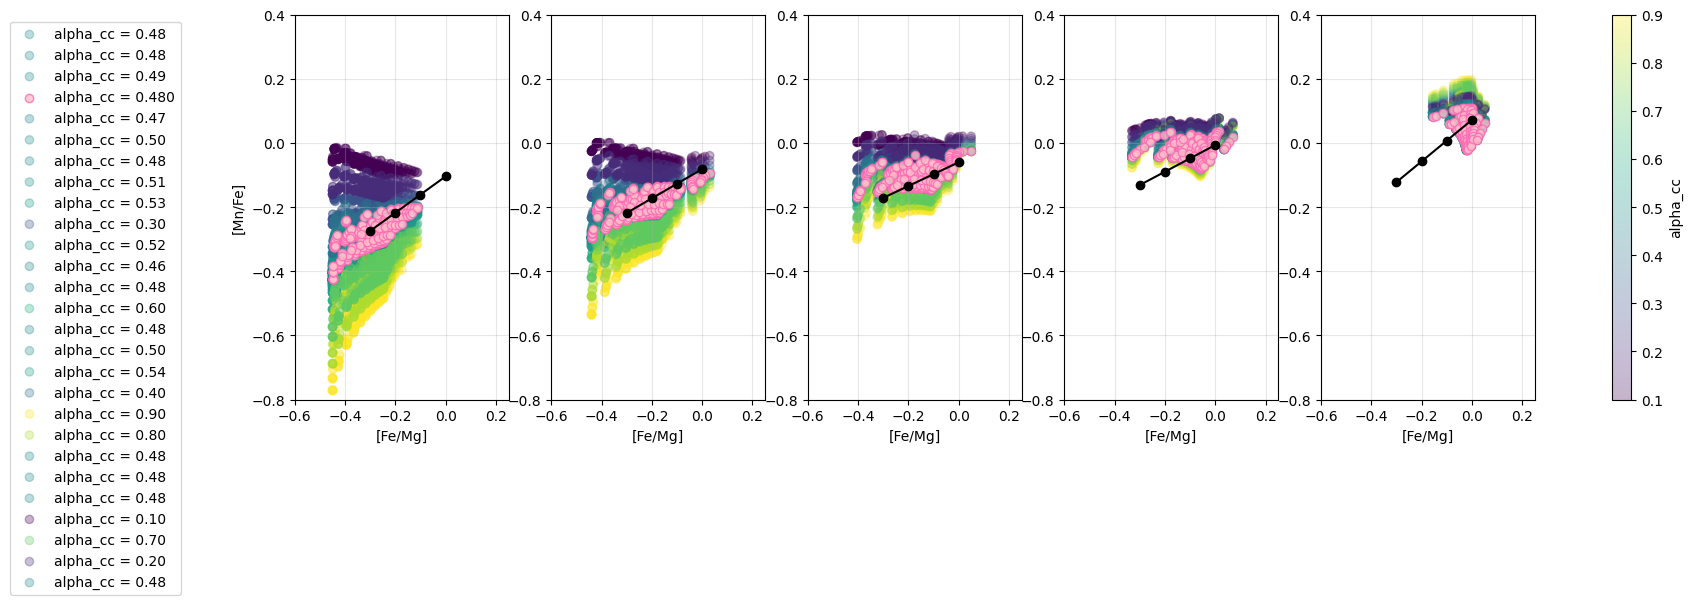

In [17]:
param_to_plot = "alpha_cc"

dfs = []
plot_file_pattern = f"models_Jul5/{param_to_plot}_*"

to_plot_files = glob.glob(plot_file_pattern)
print(to_plot_files)

for path in to_plot_files:
    dfs.append(pd.read_csv(path))

all_dfs = pd.concat(dfs, ignore_index=True)

vmin = all_dfs[param_to_plot].min()
vmax = all_dfs[param_to_plot].max()


plt.figure(figsize=(20,5))

for i in range(len(mg_h_big_bin_centers)):
    plt.subplot(1,5,i+1)
    
    for j in range(len(to_plot_files)):
        path = to_plot_files[j]
        df = pd.read_csv(path)
        mask = np.isclose(df['mg_h_bin'], mg_h_big_bin_centers[i])
        subset = df[mask]

        val = subset[param_to_plot].iloc[0]
        best_val = best_alpha_cc
        if np.isclose(val, best_val):
            plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.8, color='pink', 
                        edgecolors='hotpink', label=f"{param_to_plot} = {val:.3f}", zorder=10)
        else:
            sc = plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.3, 
                            label=f"{param_to_plot} = {val:.2f}", c=subset[param_to_plot], cmap='viridis',
                            vmin=vmin, vmax=vmax)
            
    mask_data = np.isclose(summary_df['mg_h_bin_center'], mg_h_big_bin_centers[i])
    data_subset = summary_df[mask_data]

    plt.plot(fe_mg_centers, data_subset['mn_fe_model_vals'].iloc[0], color='black', marker='o', zorder=12)

    if i == 0:
        plt.ylabel('[Mn/Fe]')
        plt.legend(bbox_to_anchor=[-0.5, 1])

    plt.grid(True, alpha=0.3)
    plt.xlim(-0.60, 0.25)
    plt.ylim(-0.8, 0.40)
    plt.xlabel('[Fe/Mg]')

cbar = plt.colorbar(sc, ax=plt.gcf().axes)
cbar.set_label(param_to_plot)

['models_Jul5/alpha_Ia_iter2_0.2602.csv', 'models_Jul5/alpha_Ia_iter2_0.2601.csv', 'models_Jul5/alpha_Ia_iter2_0.25980000000000003.csv', 'models_Jul5/alpha_Ia_iter2_0.26.csv', 'models_Jul5/alpha_Ia_iter0_0.8.csv', 'models_Jul5/alpha_Ia_iter2_0.2604.csv', 'models_Jul5/alpha_Ia_iter2_0.2599.csv', 'models_Jul5/alpha_Ia_iter1_0.32999999999999996.csv', 'models_Jul5/alpha_Ia_iter1_0.31999999999999995.csv', 'models_Jul5/alpha_Ia_iter0_0.6000000000000001.csv', 'models_Jul5/alpha_Ia_iter1_0.29.csv', 'models_Jul5/alpha_Ia_iter1_0.28.csv', 'models_Jul5/alpha_Ia_iter0_0.7000000000000001.csv', 'models_Jul5/alpha_Ia_iter1_0.31.csv', 'models_Jul5/alpha_Ia_iter0_0.30000000000000004.csv', 'models_Jul5/alpha_Ia_iter1_0.26.csv', 'models_Jul5/alpha_Ia_iter1_0.27.csv', 'models_Jul5/alpha_Ia_iter1_0.33999999999999997.csv', 'models_Jul5/alpha_Ia_iter2_0.26030000000000003.csv', 'models_Jul5/alpha_Ia_iter2_0.2597.csv', 'models_Jul5/alpha_Ia_iter1_0.3.csv', 'models_Jul5/alpha_Ia_iter2_0.2596.csv', 'models_Jul5/

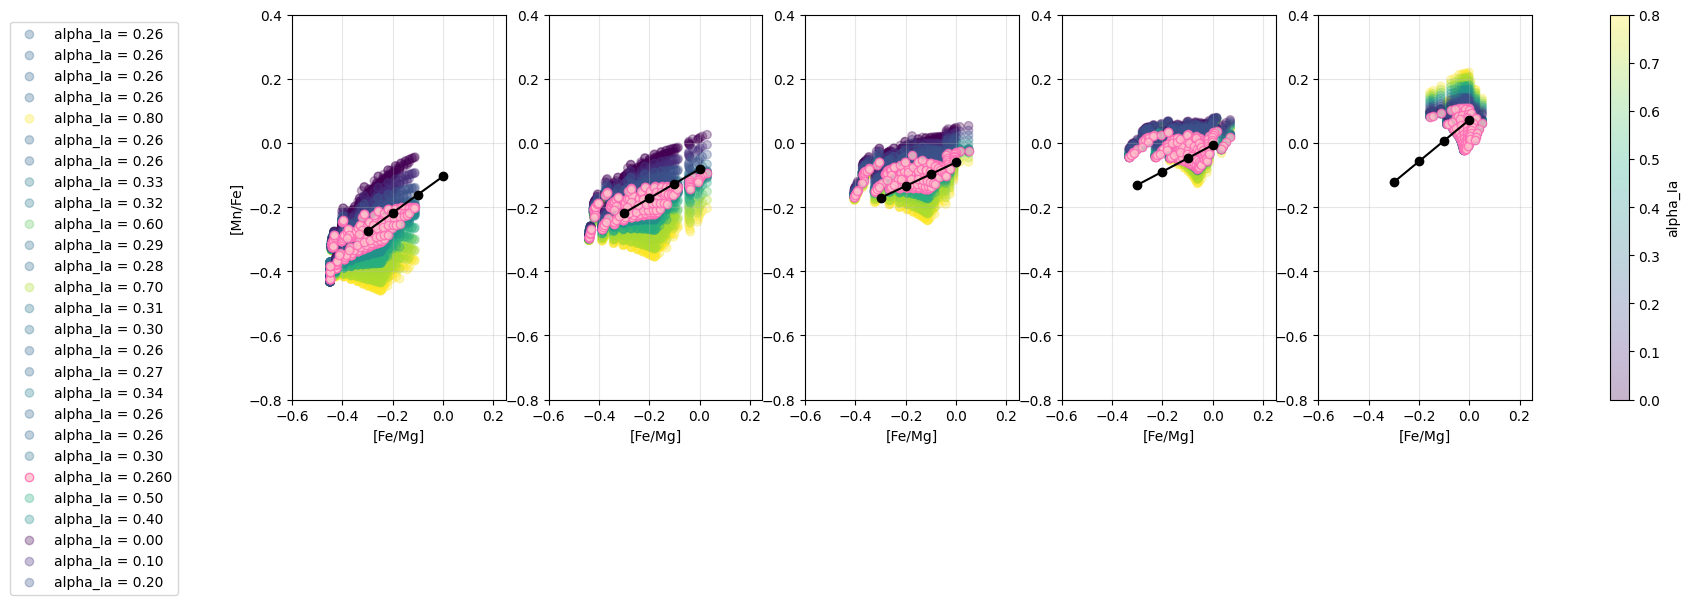

In [18]:
param_to_plot = "alpha_Ia"

dfs = []
num_plot_files = 3
plot_file_pattern = f"models_Jul5/{param_to_plot}_*"

to_plot_files = glob.glob(plot_file_pattern)
print(to_plot_files)

for path in to_plot_files:
    dfs.append(pd.read_csv(path))

all_dfs = pd.concat(dfs, ignore_index=True)

vmin = all_dfs[param_to_plot].min()
vmax = all_dfs[param_to_plot].max()


plt.figure(figsize=(20,5))

for i in range(len(mg_h_big_bin_centers)):
    plt.subplot(1,5,i+1)
    
    for j in range(len(to_plot_files)):
        path = to_plot_files[j]
        df = pd.read_csv(path)
        mask = np.isclose(df['mg_h_bin'], mg_h_big_bin_centers[i])
        subset = df[mask]

        val = subset[param_to_plot].iloc[0]
        best_val = best_alpha_Ia
        if np.isclose(val, best_val):
            plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.8, color='pink', 
                        edgecolors='hotpink', label=f"{param_to_plot} = {val:.3f}", zorder=10)
        else:
            sc = plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.3, 
                            label=f"{param_to_plot} = {val:.2f}", c=subset[param_to_plot], cmap='viridis',
                            vmin=vmin, vmax=vmax)
            
    mask_data = np.isclose(summary_df['mg_h_bin_center'], mg_h_big_bin_centers[i])
    data_subset = summary_df[mask_data]

    plt.plot(fe_mg_centers, data_subset['mn_fe_model_vals'].iloc[0], color='black', marker='o', zorder=12)

    if i == 0:
        plt.ylabel('[Mn/Fe]')
        plt.legend(bbox_to_anchor=[-0.5, 1])

    plt.grid(True, alpha=0.3)
    plt.xlim(-0.60, 0.25)
    plt.ylim(-0.8, 0.40)
    plt.xlabel('[Fe/Mg]')

cbar = plt.colorbar(sc, ax=plt.gcf().axes)
cbar.set_label(param_to_plot)

['models_Jul5/g_cc_iter1_0.36000000000000004.csv', 'models_Jul5/g_cc_iter0_0.7000000000000001.csv', 'models_Jul5/g_cc_iter0_0.2.csv', 'models_Jul5/g_cc_iter2_0.3897.csv', 'models_Jul5/g_cc_iter2_0.3896.csv', 'models_Jul5/g_cc_iter1_0.44.csv', 'models_Jul5/g_cc_iter1_0.4.csv', 'models_Jul5/g_cc_iter0_0.1.csv', 'models_Jul5/g_cc_iter0_0.0.csv', 'models_Jul5/g_cc_iter1_0.43.csv', 'models_Jul5/g_cc_iter0_0.4.csv', 'models_Jul5/g_cc_iter0_0.5.csv', 'models_Jul5/g_cc_iter2_0.39.csv', 'models_Jul5/g_cc_iter2_0.39030000000000004.csv', 'models_Jul5/g_cc_iter2_0.38980000000000004.csv', 'models_Jul5/g_cc_iter1_0.41000000000000003.csv', 'models_Jul5/g_cc_iter2_0.3901.csv', 'models_Jul5/g_cc_iter0_0.8.csv', 'models_Jul5/g_cc_iter2_0.3902.csv', 'models_Jul5/g_cc_iter1_0.42000000000000004.csv', 'models_Jul5/g_cc_iter2_0.3899.csv', 'models_Jul5/g_cc_iter2_0.3904.csv', 'models_Jul5/g_cc_iter0_0.30000000000000004.csv', 'models_Jul5/g_cc_iter1_0.38.csv', 'models_Jul5/g_cc_iter1_0.39.csv', 'models_Jul5/g_

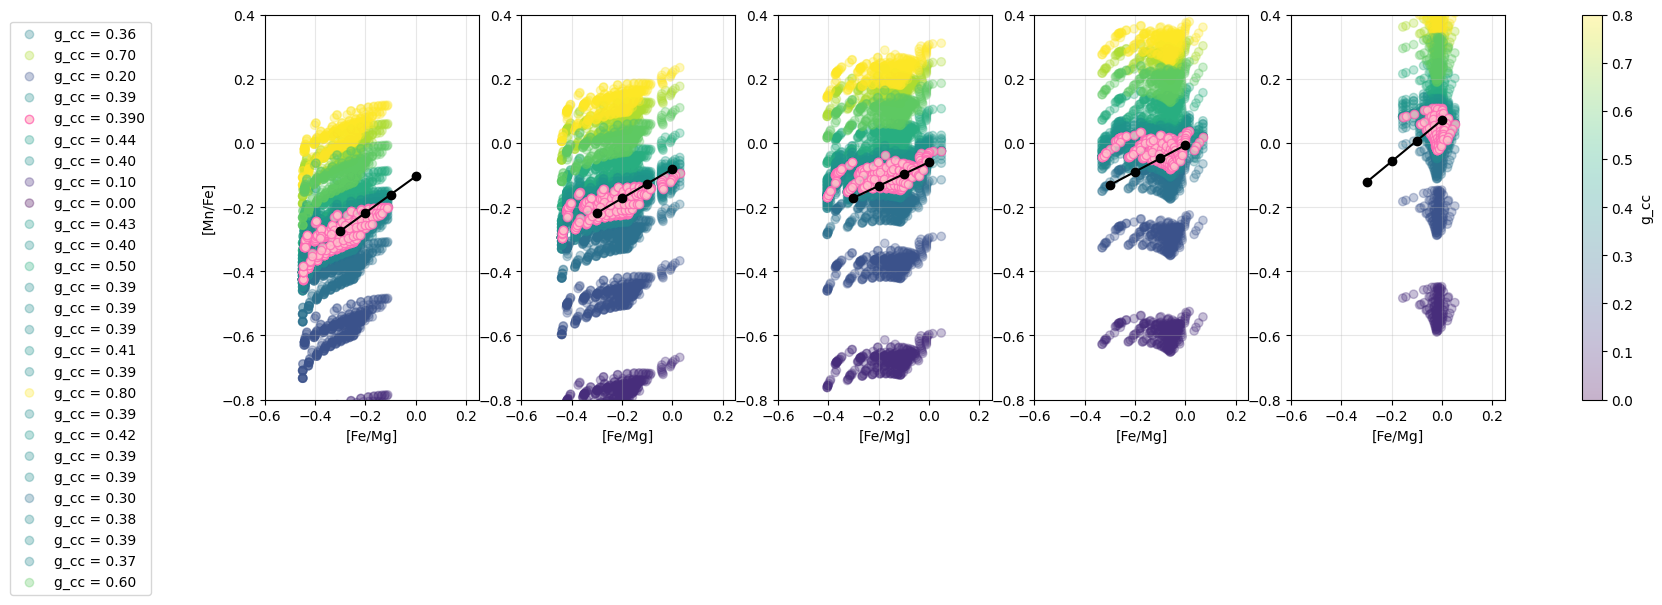

In [19]:
param_to_plot = "g_cc"

dfs = []
num_plot_files = 3
plot_file_pattern = f"models_Jul5/{param_to_plot}_*"

to_plot_files = glob.glob(plot_file_pattern)
print(to_plot_files)

for path in to_plot_files:
    dfs.append(pd.read_csv(path))

all_dfs = pd.concat(dfs, ignore_index=True)

vmin = all_dfs[param_to_plot].min()
vmax = all_dfs[param_to_plot].max()


plt.figure(figsize=(20,5))

for i in range(len(mg_h_big_bin_centers)):
    plt.subplot(1,5,i+1)
    
    for j in range(len(to_plot_files)):
        path = to_plot_files[j]
        df = pd.read_csv(path)
        mask = np.isclose(df['mg_h_bin'], mg_h_big_bin_centers[i])
        subset = df[mask]

        val = subset[param_to_plot].iloc[0]
        best_val = best_g_cc
        if np.isclose(val, best_val):
            plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.8, color='pink', 
                        edgecolors='hotpink', label=f"{param_to_plot} = {val:.3f}", zorder=10)
        else:
            sc = plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.3, 
                            label=f"{param_to_plot} = {val:.2f}", c=subset[param_to_plot], cmap='viridis',
                            vmin=vmin, vmax=vmax)
            
    mask_data = np.isclose(summary_df['mg_h_bin_center'], mg_h_big_bin_centers[i])
    data_subset = summary_df[mask_data]

    plt.plot(fe_mg_centers, data_subset['mn_fe_model_vals'].iloc[0], color='black', marker='o', zorder=12)

    if i == 0:
        plt.ylabel('[Mn/Fe]')
        plt.legend(bbox_to_anchor=[-0.5, 1])

    plt.grid(True, alpha=0.3)
    plt.xlim(-0.60, 0.25)
    plt.ylim(-0.8, 0.40)
    plt.xlabel('[Fe/Mg]')

cbar = plt.colorbar(sc, ax=plt.gcf().axes)
cbar.set_label(param_to_plot)

['models_Jul5/g_ratio_iter1_1.7.csv', 'models_Jul5/g_ratio_iter1_1.74.csv', 'models_Jul5/g_ratio_iter1_1.71.csv', 'models_Jul5/g_ratio_iter2_1.7196.csv', 'models_Jul5/g_ratio_iter0_1.5.csv', 'models_Jul5/g_ratio_iter0_2.0999999999999996.csv', 'models_Jul5/g_ratio_iter2_1.7197.csv', 'models_Jul5/g_ratio_iter1_1.66.csv', 'models_Jul5/g_ratio_iter1_1.72.csv', 'models_Jul5/g_ratio_iter0_1.6.csv', 'models_Jul5/g_ratio_iter0_1.7.csv', 'models_Jul5/g_ratio_iter1_1.73.csv', 'models_Jul5/g_ratio_iter1_1.67.csv', 'models_Jul5/g_ratio_iter0_2.3.csv', 'models_Jul5/g_ratio_iter0_2.0.csv', 'models_Jul5/g_ratio_iter2_1.72.csv', 'models_Jul5/g_ratio_iter0_1.7999999999999998.csv', 'models_Jul5/g_ratio_iter2_1.7199.csv', 'models_Jul5/g_ratio_iter2_1.7204.csv', 'models_Jul5/g_ratio_iter0_2.1999999999999997.csv', 'models_Jul5/g_ratio_iter2_1.7198.csv', 'models_Jul5/g_ratio_iter1_1.69.csv', 'models_Jul5/g_ratio_iter0_1.9.csv', 'models_Jul5/g_ratio_iter1_1.68.csv', 'models_Jul5/g_ratio_iter2_1.7202.csv', 'm

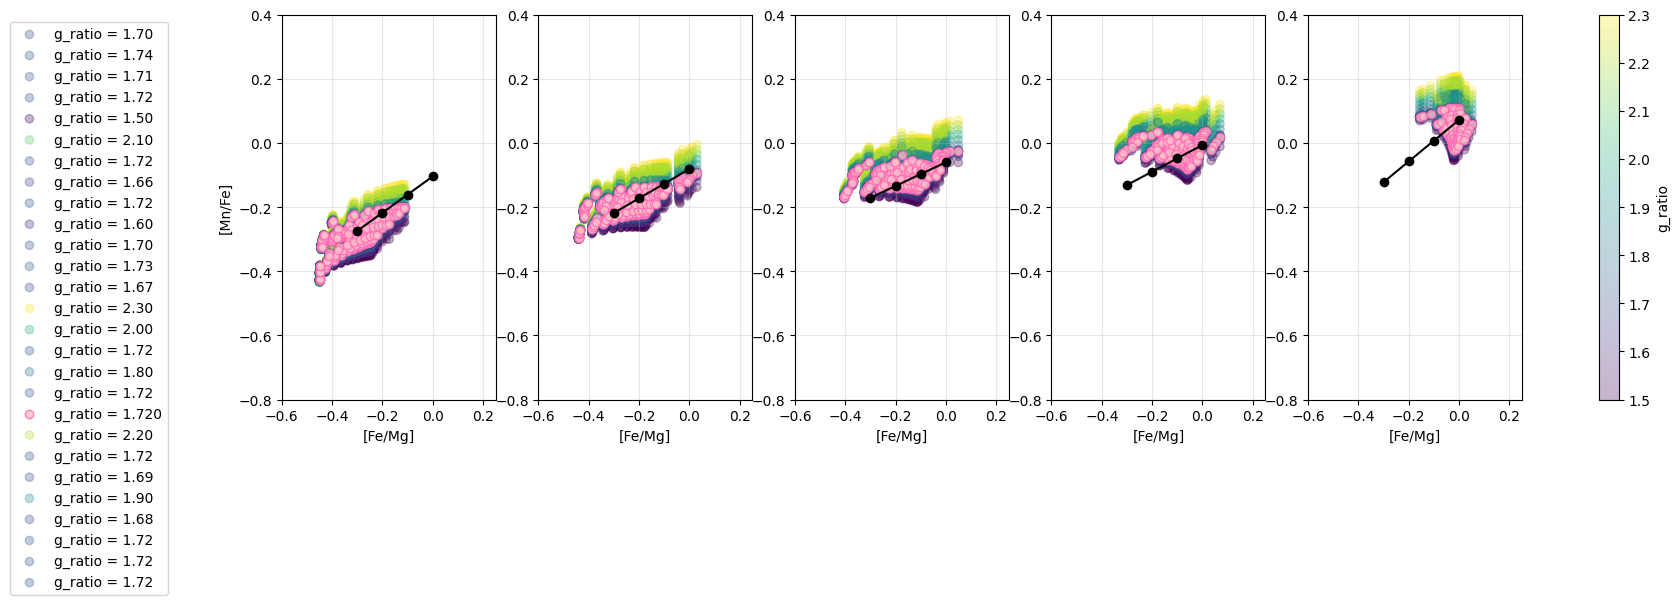

In [20]:
param_to_plot = "g_ratio"

dfs = []
num_plot_files = 3
plot_file_pattern = f"models_Jul5/{param_to_plot}_*"

to_plot_files = glob.glob(plot_file_pattern)
print(to_plot_files)

for path in to_plot_files:
    dfs.append(pd.read_csv(path))

all_dfs = pd.concat(dfs, ignore_index=True)

vmin = all_dfs[param_to_plot].min()
vmax = all_dfs[param_to_plot].max()


plt.figure(figsize=(20,5))

for i in range(len(mg_h_big_bin_centers)):
    plt.subplot(1,5,i+1)
    
    for j in range(len(to_plot_files)):
        path = to_plot_files[j]
        df = pd.read_csv(path)
        mask = np.isclose(df['mg_h_bin'], mg_h_big_bin_centers[i])
        subset = df[mask]

        val = subset[param_to_plot].iloc[0]
        best_val = best_g_ratio
        if np.isclose(val, best_val):
            plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.8, color='pink', 
                        edgecolors='hotpink', label=f"{param_to_plot} = {val:.3f}", zorder=10)
        else:
            sc = plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.3, 
                            label=f"{param_to_plot} = {val:.2f}", c=subset[param_to_plot], cmap='viridis',
                            vmin=vmin, vmax=vmax)
            
    mask_data = np.isclose(summary_df['mg_h_bin_center'], mg_h_big_bin_centers[i])
    data_subset = summary_df[mask_data]

    plt.plot(fe_mg_centers, data_subset['mn_fe_model_vals'].iloc[0], color='black', marker='o', zorder=12)

    if i == 0:
        plt.ylabel('[Mn/Fe]')
        plt.legend(bbox_to_anchor=[-0.5, 1])

    plt.grid(True, alpha=0.3)
    plt.xlim(-0.60, 0.25)
    plt.ylim(-0.8, 0.40)
    plt.xlabel('[Fe/Mg]')

cbar = plt.colorbar(sc, ax=plt.gcf().axes)
cbar.set_label(param_to_plot)

In [9]:
num_iters = 3

# 1. Store your initial parameters in a dictionary
current_params = {
    "alpha_cc": 0.50,
    "alpha_Ia": 0.40,
    "g_cc": 0.40,
    "g_ratio": 1.90
}

params_to_optimize = ["alpha_cc", "alpha_Ia", "g_cc", "g_ratio"]

for i in range(num_iters):
    for param in params_to_optimize:
        # 3. Get the newly optimized value for THIS specific parameter
        best_val = optimize_for_param(param_name=param, file_pattern=f"models_Jul5/{param}_iter{i}_*.csv")
        print(f"best {param} in iter {i} = {best_val}")

best alpha_cc in iter 0 = 0.5
best alpha_Ia in iter 0 = 0.3
best g_cc in iter 0 = 0.4
best g_ratio in iter 0 = 1.7
best alpha_cc in iter 1 = 0.48
best alpha_Ia in iter 1 = 0.26
best g_cc in iter 1 = 0.39
best g_ratio in iter 1 = 1.72
best alpha_cc in iter 2 = 0.4795999999999999
best alpha_Ia in iter 2 = 0.2596
best g_cc in iter 2 = 0.3896
best g_ratio in iter 2 = 1.7204
